# Image Caption Generator

The goal of this project is to build an algorithm that can generate a caption based on an image.

## 1.0 Setup



### Importing the libraries

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2025-07-27 21:17:20.530846: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753640240.567633  215071 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753640240.579073  215071 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753640240.610121  215071 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753640240.610158  215071 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753640240.610163  215071 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: []


2025-07-27 21:17:24.764689: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-07-27 21:17:24.764719: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-07-27 21:17:24.764726: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: ASUS-TUF-GAMING-A15
2025-07-27 21:17:24.764731: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] hostname: ASUS-TUF-GAMING-A15
2025-07-27 21:17:24.764839: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:197] libcuda reported version is: 550.144.3
2025-07-27 21:17:24.764865: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:201] kernel reported ver

In [2]:
import string
import os
import pandas
import keras
import sys
import h5py
import pprint
import argparse 
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from pickle import dump, load
from itertools import islice
from IPython.display import display
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences, to_categorical, plot_model
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add, BatchNormalization


sys.path.append(os.path.abspath("..")) 

from src import *

# small library for seeing the progress of loops.
from tqdm import tqdm_notebook as tqdm
tqdm().pandas()

/tmp/ipykernel_215071/866944354.py:30: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  tqdm().pandas()


0it [00:00, ?it/s]

### Setting up paths variables

In [3]:
# Paths to the folders and files
TOKEN_PATH = text_data_raw_dir / "Flickr8k.token.txt"
IMG_PATH = img_data_raw_dir
IMG_TEXT_FILES_PATH = text_data_raw_dir / "Flickr_8k.trainImages.txt"

In [4]:
print(f"Path to image tokens: {TOKEN_PATH}")
print(f"Path to images: {IMG_PATH}")
print(f"Path to images text filenames: {IMG_TEXT_FILES_PATH}")

Path to image tokens: /home/mahmoud/Documents/Software/ML/img_caption_generator/data/raw/Flickr8k_text/Flickr8k.token.txt
Path to images: /home/mahmoud/Documents/Software/ML/img_caption_generator/data/raw/Flickr8k_Dataset/Flicker8k_Dataset
Path to images text filenames: /home/mahmoud/Documents/Software/ML/img_caption_generator/data/raw/Flickr8k_text/Flickr_8k.trainImages.txt


### Helper Functions

In [5]:
# Create function to load the files
def load_file(filename:str):
    """
    load_file: takes a filename and loads its contents into a string

    args: 
        filename (string): path of the file that will be loaded

    returns:
        text (string): a string of all of the lines in the filename
    """

    file = open(filename, 'r')
    text = file.read()
    file.close()
    
    return text

In [6]:
# Create a function to seperate each image with its captions
def img_captions(filename:str):
    """
    img_captions: takes a file of images and all of its captions and creates a dictionary with each image 
                  as the key and the values are all of its  captions

    args:
        filename (string): the name of the file with the images and captions pair

    returns:
        image_descriptions (dictionary): a dictionary with each image as the key and its captions in a list as the value
    """

    # loading the file
    file = load_file(filename)
    captions = file.split("\n")
    image_captions = {}

    for caption in captions[:-1]: # Last line is empty so iterating up to the line before the end
        img, caption = caption.split('\t') # Splitting the image and caption using the 'tab'
        if img[:-2] not in image_captions: # Last 2 in every image has the "#" and "caption number" 
            image_captions[img[:-2]] = [caption]
        else:
            image_captions[img[:-2]].append(caption)

    return image_captions


In [7]:
img_caps = img_captions(TOKEN_PATH)

In [8]:
import pprint
from itertools import islice
pprint.pprint(dict(islice(img_caps.items(), 3)))

{'1000268201_693b08cb0e.jpg': ['A child in a pink dress is climbing up a set '
                               'of stairs in an entry way .',
                               'A girl going into a wooden building .',
                               'A little girl climbing into a wooden playhouse '
                               '.',
                               'A little girl climbing the stairs to her '
                               'playhouse .',
                               'A little girl in a pink dress going into a '
                               'wooden cabin .'],
 '1001773457_577c3a7d70.jpg': ['A black dog and a spotted dog are fighting',
                               'A black dog and a tri-colored dog playing with '
                               'each other on the road .',
                               'A black dog and a white dog with brown spots '
                               'are staring at each other in the street .',
                               'Two dogs of differ

In [9]:
# Create a function to simplify captions
def simplify(captions:dict):
    """
    simplify: takes a dictionary of image and its captions and removes punctuations, numbers, and changes uppercase letters into lowercase.

    args: 
        captions (dictionary): A dictionary of each image as the key and a list of captions as the value.

    returns:
        captions (dictionary): Returns the same dictionary after simplifying the captions 
    """
    
    table = str.maketrans("", "", string.punctuation)
    
    for img, img_captions in captions.items():
        for i, caption in enumerate(img_captions):
            
            caption.replace("-"," ") # Replacing "-" with a blank space
            words = caption.split() # Splitting each word in the dictionary

            words = [word.lower() for word in words] 
            words = [word.translate(table) for word in words] # Applying the translation table of removing the punctuation marks

            words = [word for word in words if len(word)>1] # Only keeping words that are more then 1 character long
            words = [word for word in words if word.isalpha()] # Removing numbers

            caption = " ".join(words)
            captions[img][i] = caption

    return captions

In [10]:
img_caps_simplified = simplify(img_caps)

In [11]:
pprint.pprint(dict(islice(img_caps_simplified.items(), 3)))

{'1000268201_693b08cb0e.jpg': ['child in pink dress is climbing up set of '
                               'stairs in an entry way',
                               'girl going into wooden building',
                               'little girl climbing into wooden playhouse',
                               'little girl climbing the stairs to her '
                               'playhouse',
                               'little girl in pink dress going into wooden '
                               'cabin'],
 '1001773457_577c3a7d70.jpg': ['black dog and spotted dog are fighting',
                               'black dog and tricolored dog playing with each '
                               'other on the road',
                               'black dog and white dog with brown spots are '
                               'staring at each other in the street',
                               'two dogs of different breeds looking at each '
                               'other on the road',
  

In [12]:
# Create a function to make up the vocab used in the text
def make_vocab(captions:dict):
    """
    make_vocab: takes a dictionary of image and its captions and finds all unique words used to make up a set of vocabulary

    args:
        captions (dictionary): A dictionary of each image as the key and a list of captions as the value.

    returns:
        vocab (set): A set of unique words from all the captions
    """

    vocab = set()

    for key in captions.keys():
        
        [vocab.update(c.split()) for c in captions[key]]

    return vocab   

In [13]:
vocab = make_vocab(img_caps_simplified)

In [14]:
len(vocab), list(vocab)[:10]

(8763,
 ['presents',
  'rental',
  'grandmother',
  'tread',
  'continue',
  'covers',
  'sidwalk',
  'frisbee',
  'bigwheels',
  'pedestrian'])

In [15]:
# Create a function that saves the images and its new editted captions
def save_captions(captions:dict, filename:str):
    """
    save_captions: takes the new dictionary of image and its new editted captions and saves them 
                   in the original formate of image - caption_number as a text file

    args:
        captions (dictionary): A dictionary of each image as the key and a list of captions as 
                               the value.
        
        filename (string): The filename of the text that will be saved.
    """

    lines = []
    for img, image_captions in captions.items():
        for i, caption in enumerate(image_captions):
            line = img + "\t" + caption
            lines.append(line)

    text ="\n".join(lines)
    
    file = open(filename, "w")
    file.write(text)
    file.close()

In [16]:
save_captions(img_caps_simplified, data_cleaned_dir / "Flickr8k.token_cleaned.txt")

## 2. Building a model for feature extraction

Transfer learning using the Xception model as the base model to extract features
After removing the top layers from the Xception model which is trained on the imagenet dataset in order to extract the feature vector for the images in our dataset 

### Xception base model for feature extraction

In [17]:
# xception_feature_extraction_model = keras.applications.Xception(include_top=False, pooling='average') # Don't want the final layers which output the classification prediction instead we stop at the raw features detected
# features = {}
# for img in tqdm(os.listdir(IMG_PATH)):
#     filename = IMG_PATH / img
#     image = Image.open(filename)
#     image = image.resize((299, 299))
#     image = np.expand_dims(image, axis=0) # changing the shape of the image to (1, 299, 299, 3) as keras expect the input in batches even if batch of 1.
#     image = image / 127.5
#     image = image - 1.0
    
#     feature = xception_feature_extraction_model.predict(image) # outputs the feature vector
#     features[img] = feature
    

In [18]:
# pprint.pprint(dict(islice(features.items(), 1)))

`dump()` function from the pickle module kept crashing the kernel, after testing it seems to be an issue with how large the `features` dictionary is, so had to save the features in a h5 file

In [19]:
# Saving the features vector 
# dump(features, open("../models/features.p","wb"))

In [20]:
# with h5py.File('../models/features.h5', 'w') as f:
#     for k, v in features.items():
#         f.create_dataset(k, data=np.array(v), compression="gzip")


### Loading the images

In [21]:
images = []
with open(IMG_TEXT_FILES_PATH, 'r') as f:
    img_files = f.readlines()
    for file in img_files:
        images.append(file[:-1]) 

In [22]:
len(images), images[0], images[-1]

(6000, '2513260012_03d33305cf.jpg', '2671602981_4edde92658.jpg')

### Loading each image and its captions

In [23]:
with open(data_cleaned_dir / "Flickr8k.token_cleaned.txt", 'r') as captions:
    
    # Load cleaned captions text file
    file = captions.readlines()
    descriptions = {}
    
    file = " ".join(file)

    for line in file.split("\n"):
        words = line.split() # Split each line into words --> ["img001.jpg", "man", "wears", ......]
        
        if len(words)<1:
            continue
        
        image, image_caption = words[0], words[1:]
        
        if image in images:
            # Since each image appears 5 times in the captions text file, we need to initiate it once in the descriptions dict
            # with an empty list and then append to that list each new caption after adding the start and end identifiers
            if image not in descriptions:
                descriptions[image] = []
            desc = "<start> " + " ".join(image_caption) + " <end>"
            descriptions[image].append(desc)

In [24]:
descriptions, len(descriptions)

({'1000268201_693b08cb0e.jpg': ['<start> child in pink dress is climbing up set of stairs in an entry way <end>',
   '<start> girl going into wooden building <end>',
   '<start> little girl climbing into wooden playhouse <end>',
   '<start> little girl climbing the stairs to her playhouse <end>',
   '<start> little girl in pink dress going into wooden cabin <end>'],
  '1001773457_577c3a7d70.jpg': ['<start> black dog and spotted dog are fighting <end>',
   '<start> black dog and tricolored dog playing with each other on the road <end>',
   '<start> black dog and white dog with brown spots are staring at each other in the street <end>',
   '<start> two dogs of different breeds looking at each other on the road <end>',
   '<start> two dogs on pavement moving toward each other <end>'],
  '1002674143_1b742ab4b8.jpg': ['<start> little girl covered in paint sits in front of painted rainbow with her hands in bowl <end>',
   '<start> little girl is sitting in front of large painted rainbow <end

Loading the file was also crashing the kernel so, had to load each vector iteratively.

In [25]:
features = {}
with h5py.File('../models/features.h5', 'r') as f:
    for i, k in enumerate(f.keys()):
        features[k] = f[k][()]  # Load individual array

In [26]:
pprint.pprint(dict(islice(features.items(), 1)))

{'1000268201_693b08cb0e.jpg': array([[[[0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.10360497,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.07289892,
          0.        , 0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]],

        [[0.        , 0.        , 0.        , ..., 0.01908493,
          0.        , 0.        ],
         [0.        , 0.        , 0.        , ..., 0.37761557,
          0.        , 0.17500734],
         [0.        , 0.        , 0.        , ..., 0.3012458 ,
          0.        , 0.53495836],
         ...,
         [0.        , 0.        , 0.        , ..., 0.     

In [27]:
len(features)

8091

In [28]:
image_feature_vectors = {img:np.mean(features[img][0], axis=(0, 1)) for img in images} # Reshaping the vector to (2048,) instead of (1, 10, 10, 2048)

In [29]:
image_feature_vectors["2513260012_03d33305cf.jpg"].shape

(2048,)

In [30]:
pprint.pprint(dict(islice(image_feature_vectors.items(), 1)))

{'2513260012_03d33305cf.jpg': array([0.        , 0.44787437, 0.        , ..., 0.17718253, 0.00192081,
       0.00869141], dtype=float32)}


In [31]:
len(image_feature_vectors)

6000

## 3.0 Tokenizing the vocabulary

* Step 1: Convert the disctionary of captions in to a list
* Step 2: Create a token for each word

In [32]:
# Convert the captions dict to a list of captions
all_descs = []
for img, captions in descriptions.items():
    [all_descs.append(caption) for caption in captions]

In [33]:
len(all_descs), all_descs[:10]

(30000,
 ['<start> child in pink dress is climbing up set of stairs in an entry way <end>',
  '<start> girl going into wooden building <end>',
  '<start> little girl climbing into wooden playhouse <end>',
  '<start> little girl climbing the stairs to her playhouse <end>',
  '<start> little girl in pink dress going into wooden cabin <end>',
  '<start> black dog and spotted dog are fighting <end>',
  '<start> black dog and tricolored dog playing with each other on the road <end>',
  '<start> black dog and white dog with brown spots are staring at each other in the street <end>',
  '<start> two dogs of different breeds looking at each other on the road <end>',
  '<start> two dogs on pavement moving toward each other <end>'])

In [34]:
# Initiate a tokenizer class
tk = Tokenizer()
tk.fit_on_texts(all_descs)

In [35]:
dump(tk, open("../models/tokenizer.p", 'wb'))

In [36]:
vocab_size = len(tk.word_index) + 1
vocab_size

7577

In [37]:
length_of_caps = [len(caption.split()) for caption in all_descs]
max_caps = max(length_of_caps)
max_caps

34

## 4.0 Preparing the data for the model

The model can't take all 6000 images, each one 2048 feature vector and the captions as input. So the input will be feature vector and the sequence of caption. However the 6000 images will be divided into batches.


In [38]:
descriptions

{'1000268201_693b08cb0e.jpg': ['<start> child in pink dress is climbing up set of stairs in an entry way <end>',
  '<start> girl going into wooden building <end>',
  '<start> little girl climbing into wooden playhouse <end>',
  '<start> little girl climbing the stairs to her playhouse <end>',
  '<start> little girl in pink dress going into wooden cabin <end>'],
 '1001773457_577c3a7d70.jpg': ['<start> black dog and spotted dog are fighting <end>',
  '<start> black dog and tricolored dog playing with each other on the road <end>',
  '<start> black dog and white dog with brown spots are staring at each other in the street <end>',
  '<start> two dogs of different breeds looking at each other on the road <end>',
  '<start> two dogs on pavement moving toward each other <end>'],
 '1002674143_1b742ab4b8.jpg': ['<start> little girl covered in paint sits in front of painted rainbow with her hands in bowl <end>',
  '<start> little girl is sitting in front of large painted rainbow <end>',
  '<star

In [39]:
# Create a helper function to return an image, its feature vector, and its caption
def create_sequences(tokenizer, max_length, desc_list, feature, vocab_size):
    # initialize empty lists for each parameter, where x1 is the input image, x2 is the input vector, and y is the output sequence
    x1, x2, y = list(), list(), list()
    
    # loop through each one of the 5 descriptions for each image
    for desc in desc_list:
        # encode the sequence into tokens using the tokenizer
        seq = tokenizer.texts_to_sequences([desc])[0] # Indexing on element 0 because the output is inside another vector
        
        # split the sequence into multiple X:Y pairs
        for i in range(1, len(seq)):
            # split into input and output pairs in order to predict the next word based on the previous sequence
            in_seq, out_seq = seq[:i], seq[i]
            # pad the input sequence into the max legnth
            in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
            # encode the output sequence - becomes a vector of the size of the vocab size
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            # This way the model can predict the next word based on the inupt image feature vector as well as the current input sequence
            x1.append(feature)
            x2.append(in_seq)
            y.append(out_seq)
            
    return np.array(x1), np.array(x2), np.array(y)

In [40]:
def data_generator(descriptions, features, tokenizer, max_length, vocab_size):
    while True:
        for img, description_list in descriptions.items():
            feature = features[img]
            
            input_img, input_vector, output_seq = create_sequences(tokenizer=tk, 
                                                                   max_length=max_length, 
                                                                   desc_list=description_list, 
                                                                   feature=feature, 
                                                                   vocab_size=vocab_size)
            
            yield ( (input_img, input_vector), output_seq )

In [41]:
[a,b],c = next(data_generator(descriptions=descriptions, 
                              features=image_feature_vectors, 
                              tokenizer= tk, 
                              max_length=max_caps, 
                              vocab_size=vocab_size))

In [42]:
a, a.shape, b, b.shape, c, c.shape

(array([[0.4735346 , 0.01721912, 0.07328691, ..., 0.08565868, 0.02086582,
         0.23780817],
        [0.4735346 , 0.01721912, 0.07328691, ..., 0.08565868, 0.02086582,
         0.23780817],
        [0.4735346 , 0.01721912, 0.07328691, ..., 0.08565868, 0.02086582,
         0.23780817],
        ...,
        [0.4735346 , 0.01721912, 0.07328691, ..., 0.08565868, 0.02086582,
         0.23780817],
        [0.4735346 , 0.01721912, 0.07328691, ..., 0.08565868, 0.02086582,
         0.23780817],
        [0.4735346 , 0.01721912, 0.07328691, ..., 0.08565868, 0.02086582,
         0.23780817]], dtype=float32),
 (47, 2048),
 array([[ 2,  0,  0, ...,  0,  0,  0],
        [ 2, 42,  0, ...,  0,  0,  0],
        [ 2, 42,  3, ...,  0,  0,  0],
        ...,
        [ 2, 39, 18, ...,  0,  0,  0],
        [ 2, 39, 18, ...,  0,  0,  0],
        [ 2, 39, 18, ...,  0,  0,  0]], dtype=int32),
 (47, 34),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 

## 5.0 Training the model

### Baseline model

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 34, 256)   │  1,939,712 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 34, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 34)        │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7577)      │  1,947,289 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,002,649 (19.08 MB)

 Trainable params: 5,002,649 (19.08 MB)

 Non-trainable params: 0 (0.00 B)

None


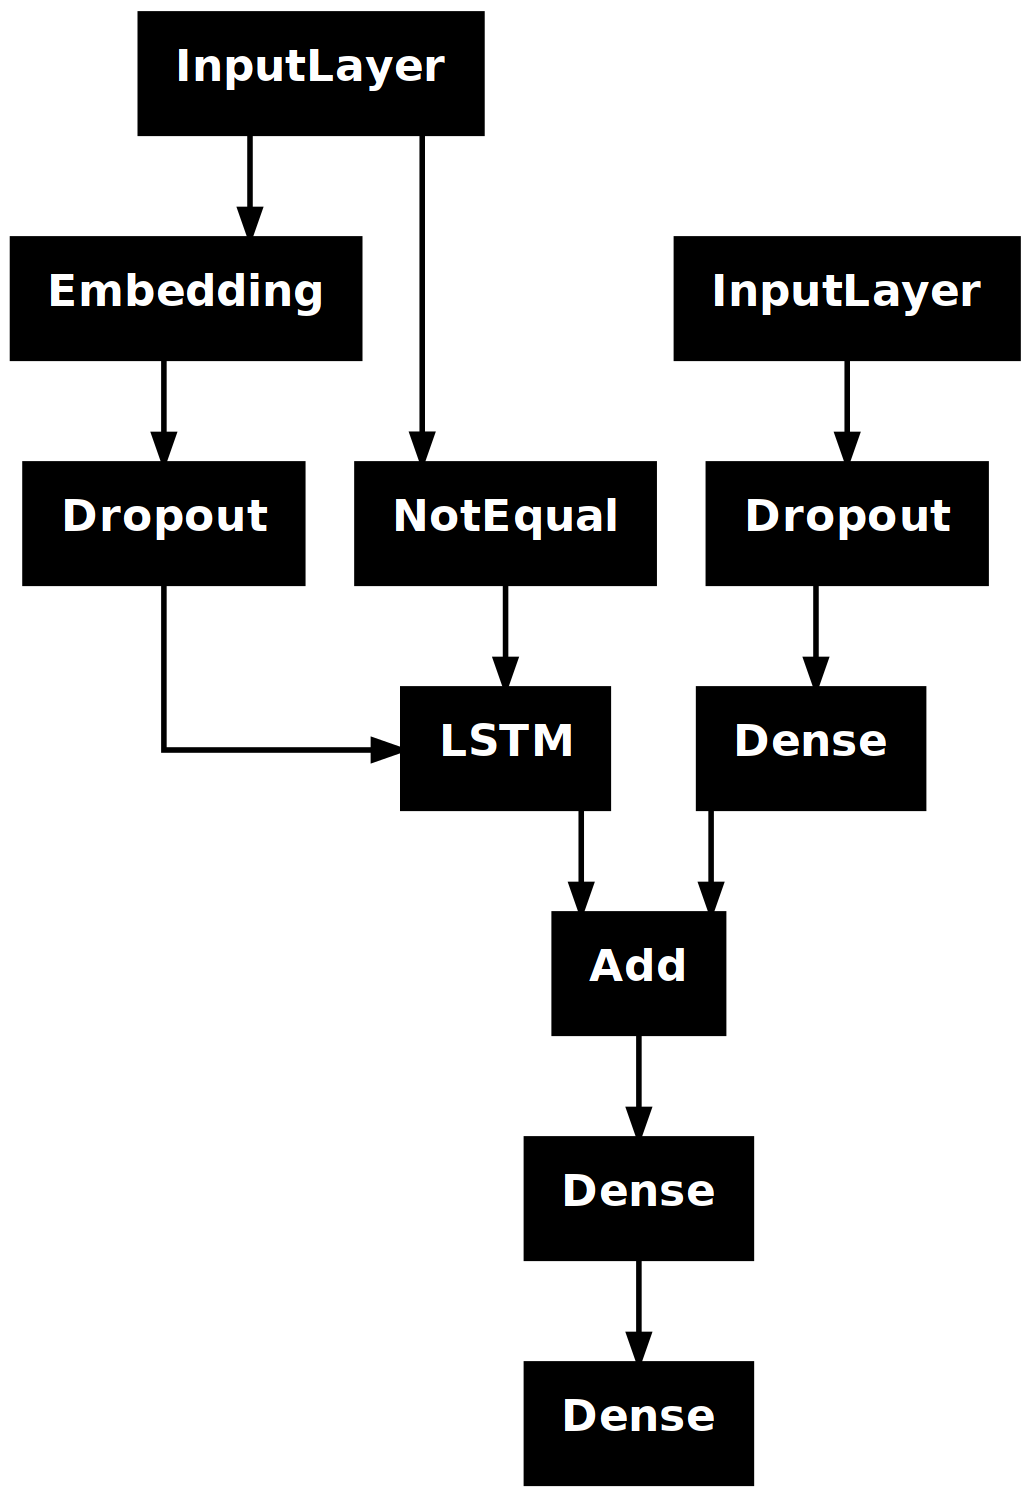

In [ ]:
# CNN model inputs
img_inputs = Input(shape=(2048,))
fe1 = Dropout(0.5)(img_inputs)
fe2 = Dense(256)(fe1)

# LSTM model inputs
seq_inputs = Input(shape=(max_caps,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(seq_inputs)
se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

# Adding the models
decoder1 = Add()([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[img_inputs, seq_inputs], 
              outputs=outputs)
model.compile(loss='categorical_crossentropy',
              optimizer='Adam')

print(model.summary())
plot_model(model, to_file='../models/models_summary/base_line_model.png')

In [44]:
print('Dataset: ', len(images))
print('Descriptions: ', len(descriptions))
print('Photos: ', len(image_feature_vectors))
print('Vocabulary Size:', vocab_size)
print('Description Length: ', max_caps)

Dataset:  6000
Descriptions:  6000
Photos:  6000
Vocabulary Size: 7577
Description Length:  34


In [45]:
# # Base model training

# EPOCHS = 5
# STEPS = len(descriptions)

# for i in range(EPOCHS):
    
#     model.fit(data_generator(descriptions=descriptions,
#                              features=image_feature_vectors,
#                              tokenizer=tk,
#                              max_length=max_caps,
#                              vocab_size=vocab_size),
#               epochs=1, 
#               steps_per_epoch=STEPS, 
#               verbose=1)
    
#     model.save("../models/baseline_model/baseline_model_" + str(i) + ".keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


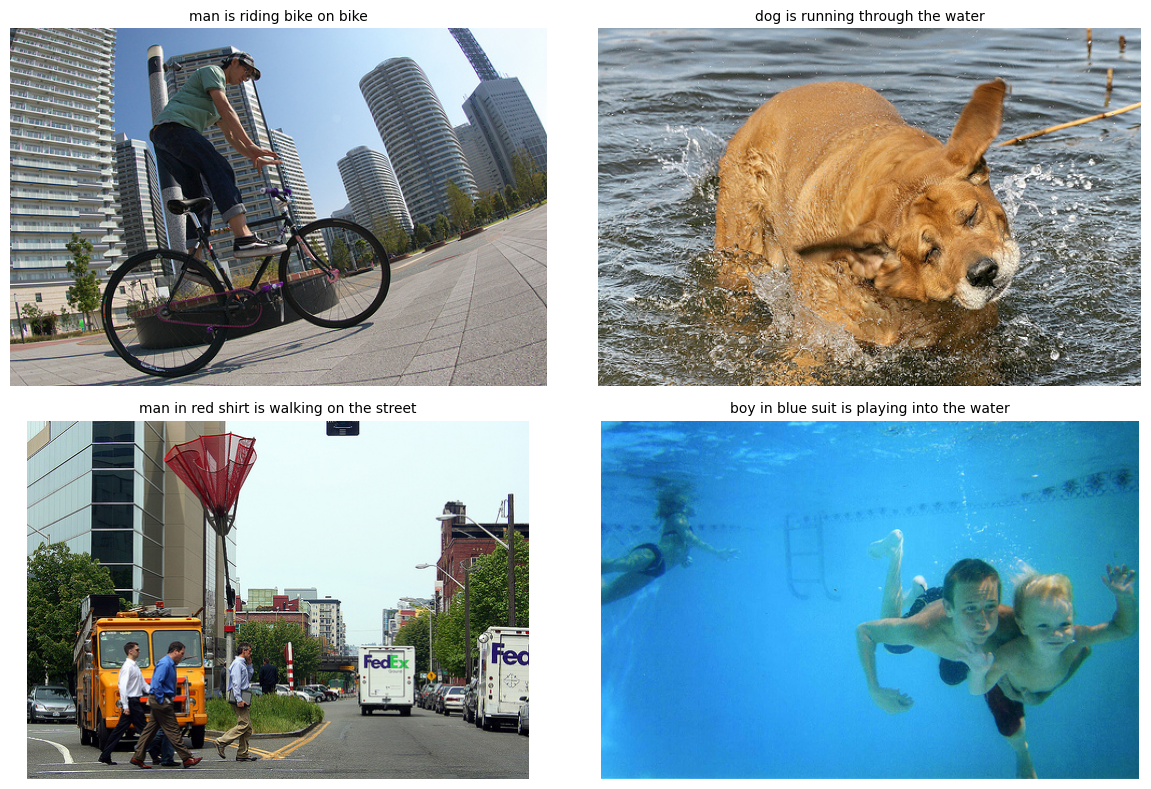

In [51]:
model = load_model("../models/baseline_model/baseline_model_4.keras")

features = load_testing_imgs(directory="../data/raw/Flickr8k_Dataset/Flicker8k_Dataset",
                             txt_file="../data/raw/Flickr8k_text/Flickr_8k.devImages.txt")

caps = generate_captions_for_images(model=model, 
                                    tokenizer=tk, 
                                    features=features, 
                                    max_length=max_caps)

display_images_with_captions(
    captions_dict=caps,
    image_dir="../data/raw/testing_images"
)